# Campaign Strategy Evaluation
### Small-party perspective (5–10% starting share)

| Section | What is evaluated |
|---|---|
| 1 · Setup | Template, fixed voter-behaviour parameters, MC runner |
| 2 · Strategy grid | Mean Δshare for every movement × spend combination, including no-spend |
| 3 · Threshold survival | P(final share ≥ 5%) for every combination |
| 4 · Outcome distributions | Full final-share distribution for each strategy |
| 5 · Budget sensitivity | How mean share, downside floor, and survival rate change with budget |
| 6 · Effectiveness sensitivity | How strategy rankings shift as ad conversion rate varies |

**Voter behaviour parameters (`tactical`, `bandwagon`, `anti_leader`, `loyalty`) are held constant throughout.**

---
## 1 · Setup

In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

from simulation import (
    get_template,
    simulate,
    get_daily_spend,
    STRATEGY_NAMES,
    SPEND_STRATEGIES)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

# ── Targets ────────────────────────────────────────────────────────────────
TEMPLATE       = "Slovakia"
CAMPAIGN_PARTY = "Demokrati"
THRESHOLD      = 0.05

# ── Run budget ─────────────────────────────────────────────────────────────
RUNS           = 1000
BUDGET         = 2.0
EFFECTIVENESS  = 0.001

# ── Fixed voter-behaviour params (never varied) ────────────────────────────
PARAMS = dict(
    poll_interval = 7,
    tactical      = 0.40,
    bandwagon     = 0.05,
    anti_leader   = 0.10,
    loyalty       = 0.80,
    poll_size     = 1000,
)

# ── Load template ──────────────────────────────────────────────────────────
rng0 = np.random.default_rng(42)
coords, names, shares = get_template(TEMPLATE, None, rng0)

try:
    campaign_idx = names.index(CAMPAIGN_PARTY)
except ValueError:
    raise ValueError(f"{CAMPAIGN_PARTY!r} not found; available: {names}")

print(f"Template : {TEMPLATE}")
print(f"Party    : {CAMPAIGN_PARTY}  (index {campaign_idx})")
print(f"Starting share : {shares[campaign_idx]:.1%}")
print(f"Parties  : {names}")

Template : Slovakia
Party    : Demokrati  (index 9)
Starting share : 6.0%
Parties  : ['Smer', 'PS', 'Hlas', 'KDH', 'SaS', 'SNS', 'Republika', 'Slovensko', 'Aliancia', 'Demokrati', 'Sme Rodina', 'Právo na Pravdu', 'ĽSNS']


In [9]:
def run_mc_fast(
    movement_strategy,
    spend_strategy,
    total_budget,
    effectiveness,
    n_runs=RUNS,
    seed_offset=1000,
    return_trajectories=False,
):
    daily_spend = get_daily_spend(spend_strategy, total_budget * 100)
    finals, wins, trajectories = [], [], []

    for run in range(n_runs):
        history, _ = simulate(
            shares=shares,
            coords_in=coords,
            names=names,
            campaign_idx=campaign_idx,
            daily_spend=daily_spend,
            movement_strategy=movement_strategy,
            effectiveness=effectiveness,
            seed=seed_offset + run,
            **PARAMS,
        )
        f = history[-1, campaign_idx]
        finals.append(f)
        wins.append(int(np.argmax(history[-1]) == campaign_idx))
        if return_trajectories:
            trajectories.append(history[:, campaign_idx])

    finals = np.array(finals)
    out = dict(
        finals       = finals,
        mean         = finals.mean(),
        std          = finals.std(),
        p10          = np.percentile(finals, 10),
        p25          = np.percentile(finals, 25),
        p75          = np.percentile(finals, 75),
        p90          = np.percentile(finals, 90),
        win_rate     = np.mean(wins),
        survive_rate = (finals >= THRESHOLD).mean(),
    )
    if return_trajectories:
        out["trajectories"] = np.array(trajectories)
    return out

print("Runner defined.")

Runner defined.


---
## 2 · Strategy grid

Mean Δshare vs no-campaign baseline for every (movement × spend) combination.
The **No spend** column isolates the effect of position movement alone, with no advertising budget.

In [10]:
# ── Baseline (no campaign at all) ──────────────────────────────────────────
print("Running baseline…")
base = run_mc_fast(
    movement_strategy="None (hold position)",
    spend_strategy="Uniform",
    total_budget=0.0,
    effectiveness=0.0,
)
print(f"  Baseline mean = {base['mean']:.2%}  survive = {base['survive_rate']:.1%}")

# ── Full grid: No spend + all spend strategies × all movement strategies ───
# "No spend" = movement only, budget=0, no ad conversion
ALL_SPEND_COLS = ["No spending"] + SPEND_STRATEGIES
records = []
total   = len(ALL_SPEND_COLS) * len(STRATEGY_NAMES)
done    = 0

for spend_label in ALL_SPEND_COLS:
    for move in STRATEGY_NAMES:
        done += 1
        print(f"  [{done}/{total}] {move} × {spend_label}")

        if spend_label == "No spend":
            r = run_mc_fast(move, "Uniform", 0.0, 0.0)
        else:
            r = run_mc_fast(move, spend_label, BUDGET, EFFECTIVENESS)

        records.append(dict(
            movement     = move,
            spend        = spend_label,
            mean         = r["mean"],
            std          = r["std"],
            p10          = r["p10"],
            p90          = r["p90"],
            win_rate     = r["win_rate"],
            survive_rate = r["survive_rate"],
            delta_mean   = r["mean"] - base["mean"],
            delta_surv   = r["survive_rate"] - base["survive_rate"],
            sharpe       = (r["mean"] - base["mean"]) / r["std"] if r["std"] > 0 else 0,
            cvar10       = r["p10"],
            finals       = r["finals"],
        ))

df = pd.DataFrame(records)
print("\nDone. Top 5 by Δmean:")
df.sort_values("delta_mean", ascending=False)[
    ["movement", "spend", "delta_mean", "std", "survive_rate", "win_rate"]
].head()

Running baseline…
  Baseline mean = 3.64%  survive = 25.9%
  [1/24] None (hold position) × No spending
  [2/24] Drift to Centre × No spending
  [3/24] Oppose Leader × No spending
  [4/24] Mirror Leader × No spending
  [5/24] Siphon Small Parties × No spending
  [6/24] Middle Ground × No spending
  [7/24] None (hold position) × Uniform
  [8/24] Drift to Centre × Uniform
  [9/24] Oppose Leader × Uniform
  [10/24] Mirror Leader × Uniform
  [11/24] Siphon Small Parties × Uniform
  [12/24] Middle Ground × Uniform
  [13/24] None (hold position) × Front-loaded
  [14/24] Drift to Centre × Front-loaded
  [15/24] Oppose Leader × Front-loaded
  [16/24] Mirror Leader × Front-loaded
  [17/24] Siphon Small Parties × Front-loaded
  [18/24] Middle Ground × Front-loaded
  [19/24] None (hold position) × Back-loaded
  [20/24] Drift to Centre × Back-loaded
  [21/24] Oppose Leader × Back-loaded
  [22/24] Mirror Leader × Back-loaded
  [23/24] Siphon Small Parties × Back-loaded
  [24/24] Middle Ground × Back

,movement,spend,delta_mean,std,survive_rate,win_rate
14,Oppose Leader,Front-loaded,0.028868,0.037580,0.608,0.002
8,Oppose Leader,Uniform,0.027271,0.037657,0.578,0.000
20,Oppose Leader,Back-loaded,0.025620,0.037131,0.536,0.001
16,Siphon Small Parties,Front-loaded,0.021217,0.032909,0.532,0.002
22,Siphon Small Parties,Back-loaded,0.020179,0.031585,0.515,0.001


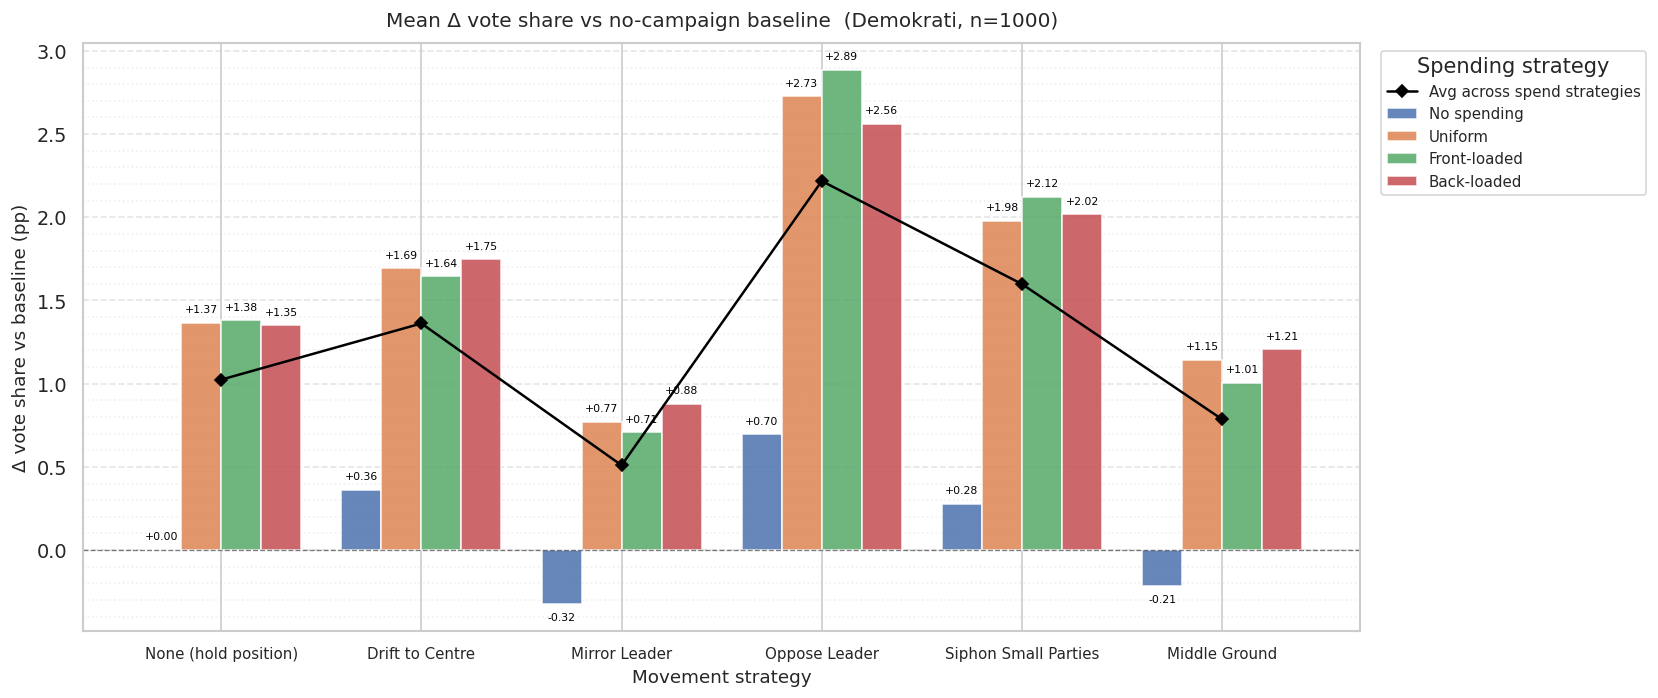

In [11]:
MOVEMENT_ORDER = [
    "None (hold position)",
    "Drift to Centre",
    "Mirror Leader",
    "Oppose Leader",
    "Siphon Small Parties",
    "Middle Ground",
]

def _pivot(col):
    p = df.pivot(index="movement", columns="spend", values=col)
    return p[ALL_SPEND_COLS].reindex(MOVEMENT_ORDER)

pivot_dm  = _pivot("delta_mean")
pivot_std = _pivot("std")

x = np.arange(len(MOVEMENT_ORDER))
n_groups = len(ALL_SPEND_COLS)
bar_width = 0.8 / n_groups
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(14, 6))

for i, spend in enumerate(ALL_SPEND_COLS):
    offsets = x + (i - n_groups / 2 + 0.5) * bar_width
    means   = pivot_dm[spend].values * 100

    bars = ax.bar(
        offsets, means,
        width=bar_width,
        label=spend,
        color=colors[i % len(colors)],
        alpha=0.85,
    )

    # Exact value labels above/below each bar
    for offset, val in zip(offsets, means):
        ax.text(
            offset,
            val + (0.05 if val >= 0 else -0.05),
            f"{val:+.2f}",
            ha="center",
            va="bottom" if val >= 0 else "top",
            fontsize=6.5,
            color="black",
        )

# Average across all spending strategies per movement strategy
movement_means = pivot_dm.mean(axis=1).values * 100
ax.plot(
    x, movement_means,
    color="black", linewidth=1.5, linestyle="-",
    marker="D", markersize=5,
    label="Avg across spend strategies",
    zorder=5,
)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(MOVEMENT_ORDER, rotation=0, ha="center", fontsize=9)
ax.set_xlabel("Movement strategy", fontsize=11)
ax.set_ylabel("Δ vote share vs baseline (pp)", fontsize=11)
ax.set_title(
    f"Mean Δ vote share vs no-campaign baseline  ({CAMPAIGN_PARTY}, n={RUNS})",
    fontsize=12, pad=10,
)
ax.legend(title="Spending strategy", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.1))
ax.yaxis.grid(True, which="major", linestyle="--", alpha=0.5)
ax.yaxis.grid(True, which="minor", linestyle=":", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

---
## 3 · Threshold survival

P(final share ≥ 5%) and Δ vs no-campaign baseline for every combination.
For a party starting near the threshold, survival probability is often more decision-relevant than mean share.

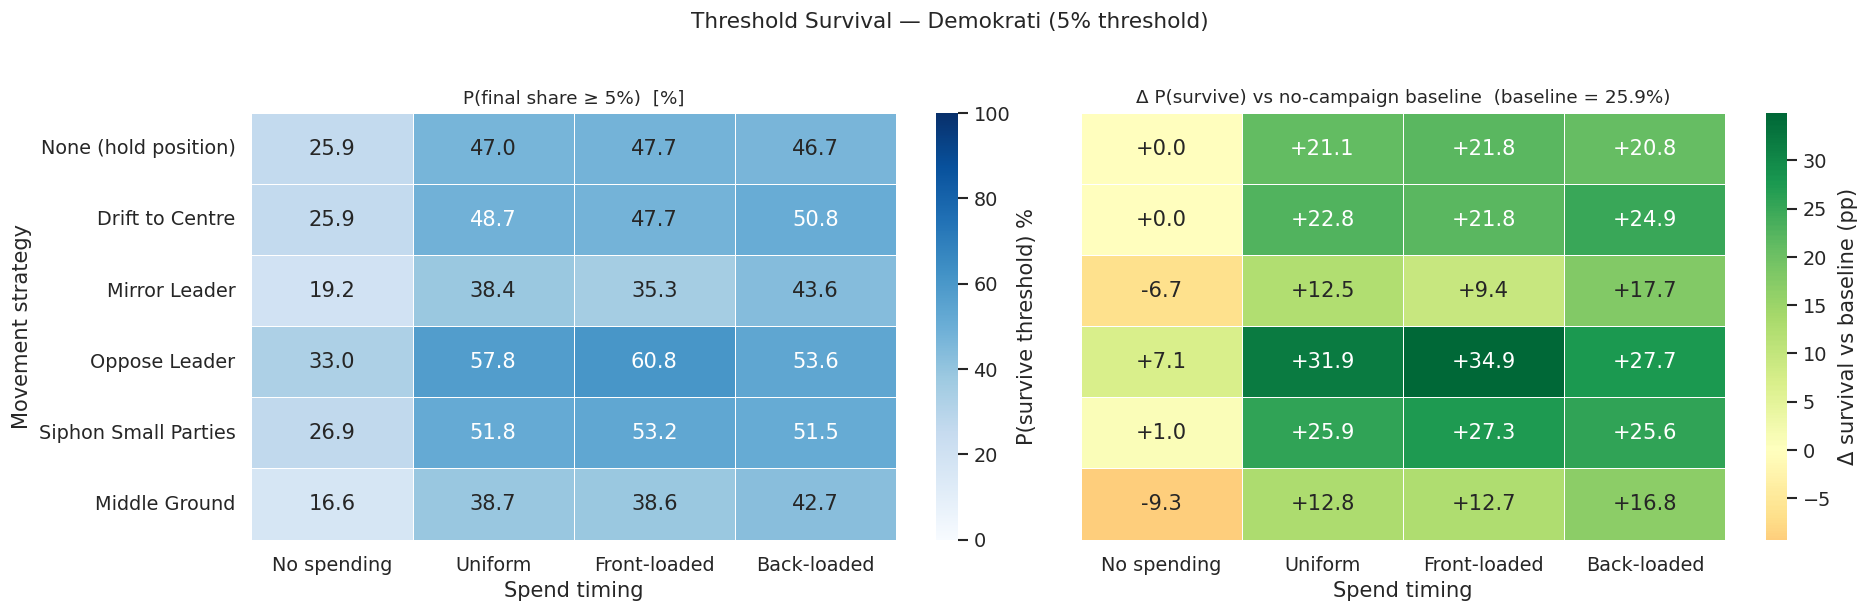

In [12]:
pivot_surv  = _pivot("survive_rate")
pivot_dsurv = _pivot("delta_surv")

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Left: absolute survival rate
sns.heatmap(
    pivot_surv * 100,
    annot=True, fmt=".1f",
    cmap="Blues", vmin=0, vmax=100,
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={"label": "P(survive threshold) %"},
)
axes[0].set_title("P(final share \u2265 5%)  [%]", fontsize=11)
axes[0].set_xlabel("Spend timing")
axes[0].set_ylabel("Movement strategy")

# Right: delta vs baseline
sns.heatmap(
    pivot_dsurv * 100,
    annot=True, fmt="+.1f",
    cmap="RdYlGn", center=0,
    linewidths=0.5,
    ax=axes[1],
    cbar_kws={"label": "\u0394 survival vs baseline (pp)"},
)
axes[1].set_title(
    f"\u0394 P(survive) vs no-campaign baseline  (baseline = {base['survive_rate']:.1%})",
    fontsize=11,
)
axes[1].set_xlabel("Spend timing")
axes[1].set_ylabel("")

plt.suptitle(
    f"Threshold Survival \u2014 {CAMPAIGN_PARTY} (5% threshold)",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

---
## 4 · Outcome distributions

KDE (Kernel Density Estimation) of final vote share for every movement strategy at the best-performing spend timing, plus the no-campaign baseline.
Reveals differences in spread and tail risk that summary statistics hide.

Best spend timing: Back-loaded


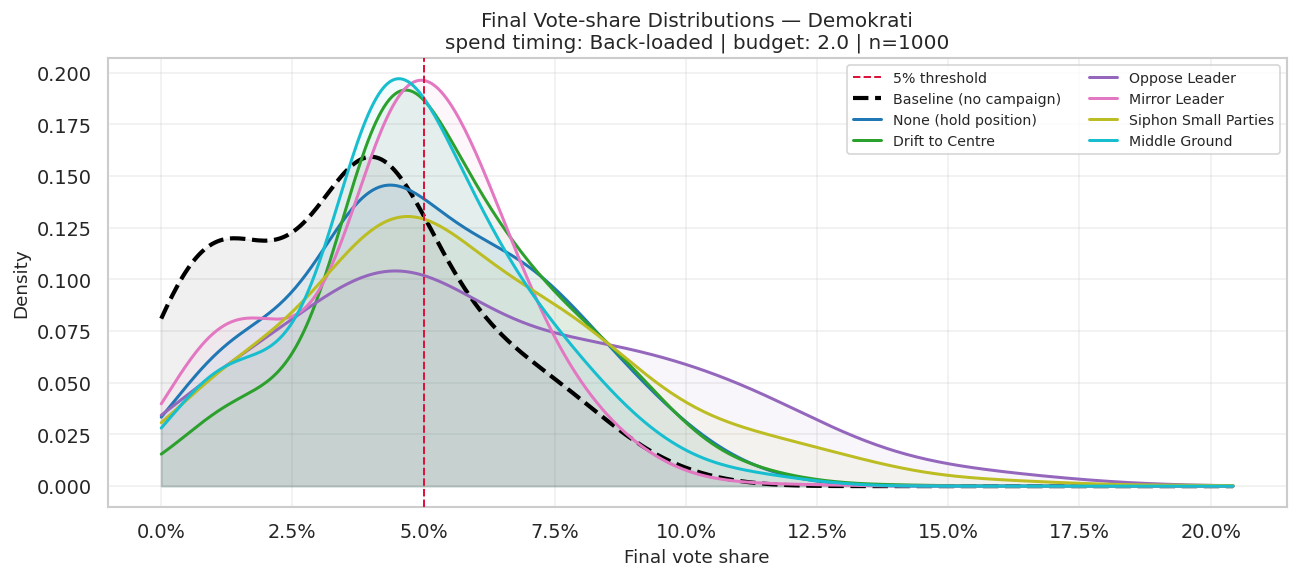

In [13]:
# Best spend timing by average delta_mean across movement strategies (excluding No spend)
best_spend_global = (
    df[df["spend"] != "No spend"]
    .groupby("spend")["delta_mean"].mean()
    .idxmax()
)
print(f"Best spend timing: {best_spend_global}")

cmap_k = plt.cm.get_cmap("tab10", len(STRATEGY_NAMES))

# Reuse finals already stored in df — no extra simulation runs needed
all_finals = {"Baseline (no campaign)": base["finals"]}
for move in STRATEGY_NAMES:
    row = df[(df["movement"] == move) & (df["spend"] == best_spend_global)]
    if not row.empty:
        all_finals[move] = row.iloc[0]["finals"]

fig, ax = plt.subplots(figsize=(11, 5))
ax.axvline(THRESHOLD * 100, color="crimson", linestyle="--",
           linewidth=1.2, label="5% threshold", zorder=5)

x_max = max(v.max() for v in all_finals.values()) * 100 * 1.05
xs    = np.linspace(0, x_max, 400)

for i, (label, vals) in enumerate(all_finals.items()):
    is_base = label == "Baseline (no campaign)"
    color   = "black" if is_base else cmap_k(i - 1)
    lw      = 2.5 if is_base else 1.8
    ls      = "--" if is_base else "-"
    kde     = stats.gaussian_kde(vals * 100, bw_method=0.4)
    ax.plot(xs, kde(xs), color=color, linewidth=lw, linestyle=ls, label=label)
    ax.fill_between(xs, kde(xs), alpha=0.06, color=color)

ax.set_xlabel("Final vote share", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title(
    f"Final Vote-share Distributions \u2014 {CAMPAIGN_PARTY}\n"
    f"spend timing: {best_spend_global} | budget: {BUDGET} | n={RUNS}",
    fontsize=12,
)
ax.legend(fontsize=8.5, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5 · Budget sensitivity

Mean share, 10th-percentile floor, and survival rate as a function of total budget for every movement strategy.
Identifies the point of diminishing returns and whether extra spend materially changes threshold risk across the full strategy set.

Strategies: ['None (hold position)', 'Drift to Centre', 'Oppose Leader', 'Mirror Leader', 'Siphon Small Parties', 'Middle Ground']
  [1/300] None (hold position) | budget=0.00
  [2/300] None (hold position) | budget=0.10
  [3/300] None (hold position) | budget=0.20
  [4/300] None (hold position) | budget=0.31
  [5/300] None (hold position) | budget=0.41
  [6/300] None (hold position) | budget=0.51
  [7/300] None (hold position) | budget=0.61
  [8/300] None (hold position) | budget=0.71
  [9/300] None (hold position) | budget=0.82
  [10/300] None (hold position) | budget=0.92
  [11/300] None (hold position) | budget=1.02
  [12/300] None (hold position) | budget=1.12
  [13/300] None (hold position) | budget=1.22
  [14/300] None (hold position) | budget=1.33
  [15/300] None (hold position) | budget=1.43
  [16/300] None (hold position) | budget=1.53
  [17/300] None (hold position) | budget=1.63
  [18/300] None (hold position) | budget=1.73
  [19/300] None (hold position) | budget=1.84
  [2

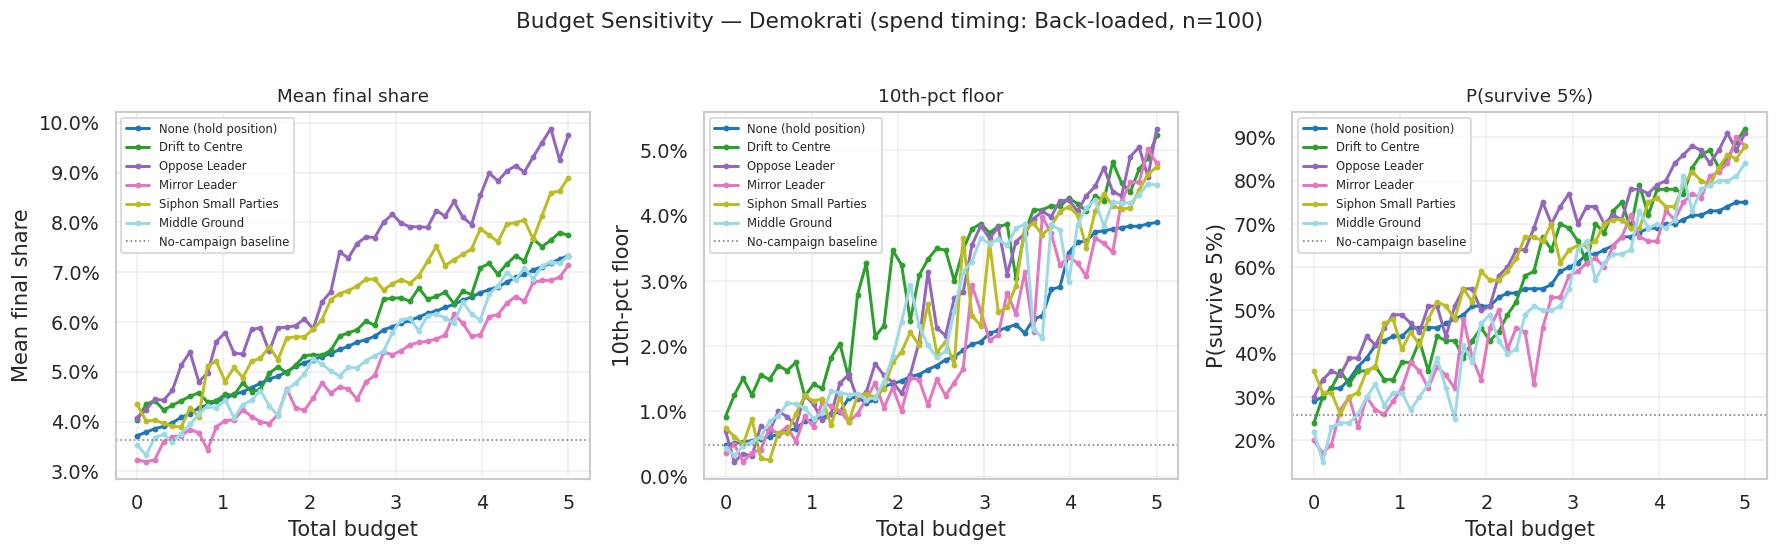

In [14]:
BGT_N_RUNS   = 100
BUDGET_SWEEP = np.linspace(0, 5, 50)

budget_moves = list(STRATEGY_NAMES)
print("Strategies:", budget_moves)

bsweep_records = []
total_b = len(budget_moves) * len(BUDGET_SWEEP)
done_b  = 0

for move in budget_moves:
    for bgt in BUDGET_SWEEP:
        done_b += 1
        print(f"  [{done_b}/{total_b}] {move} | budget={bgt:.2f}")
        r = run_mc_fast(move, best_spend_global, bgt, EFFECTIVENESS, n_runs=BGT_N_RUNS)
        bsweep_records.append(dict(
            movement     = move,
            budget       = bgt,
            mean         = r["mean"],
            p10          = r["p10"],
            survive_rate = r["survive_rate"],
        ))

df_bsweep = pd.DataFrame(bsweep_records)
cmap_b    = plt.cm.get_cmap("tab20", len(budget_moves))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
metrics   = [
    ("mean",         "Mean final share"),
    ("p10",          "10th-pct floor"),
    ("survive_rate", "P(survive 5%)"),
]

for ax, (col, ylabel) in zip(axes, metrics):
    for i, move in enumerate(budget_moves):
        sub = df_bsweep[df_bsweep["movement"] == move]
        ax.plot(sub["budget"], sub[col] * 100, marker=".", markersize=5,
                color=cmap_b(i), label=move, linewidth=1.8)
    ref = {"mean": base["mean"], "p10": base["p10"],
           "survive_rate": base["survive_rate"]}[col]
    ax.axhline(ref * 100, color="gray", linestyle=":", linewidth=1,
               label="No-campaign baseline")
    ax.set_xlabel("Total budget")
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(ylabel, fontsize=11)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Budget Sensitivity \u2014 {CAMPAIGN_PARTY} (spend timing: {best_spend_global}, n={BGT_N_RUNS})",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

---
## 6 · Effectiveness sensitivity

Mean share, 10th-percentile floor, and survival rate as a function of ad conversion rate for every movement strategy.
Shows whether strategy rankings are stable across a wide range of ad effectiveness assumptions.

Strategies: ['None (hold position)', 'Drift to Centre', 'Oppose Leader', 'Mirror Leader', 'Siphon Small Parties', 'Middle Ground']
  [1/300] None (hold position) | eff=0.0001
  [2/300] None (hold position) | eff=0.0002
  [3/300] None (hold position) | eff=0.0003
  [4/300] None (hold position) | eff=0.0004
  [5/300] None (hold position) | eff=0.0005
  [6/300] None (hold position) | eff=0.0006
  [7/300] None (hold position) | eff=0.0007
  [8/300] None (hold position) | eff=0.0008
  [9/300] None (hold position) | eff=0.0009
  [10/300] None (hold position) | eff=0.0010
  [11/300] None (hold position) | eff=0.0011
  [12/300] None (hold position) | eff=0.0012
  [13/300] None (hold position) | eff=0.0013
  [14/300] None (hold position) | eff=0.0014
  [15/300] None (hold position) | eff=0.0015
  [16/300] None (hold position) | eff=0.0016
  [17/300] None (hold position) | eff=0.0017
  [18/300] None (hold position) | eff=0.0018
  [19/300] None (hold position) | eff=0.0019
  [20/300] None (hold p

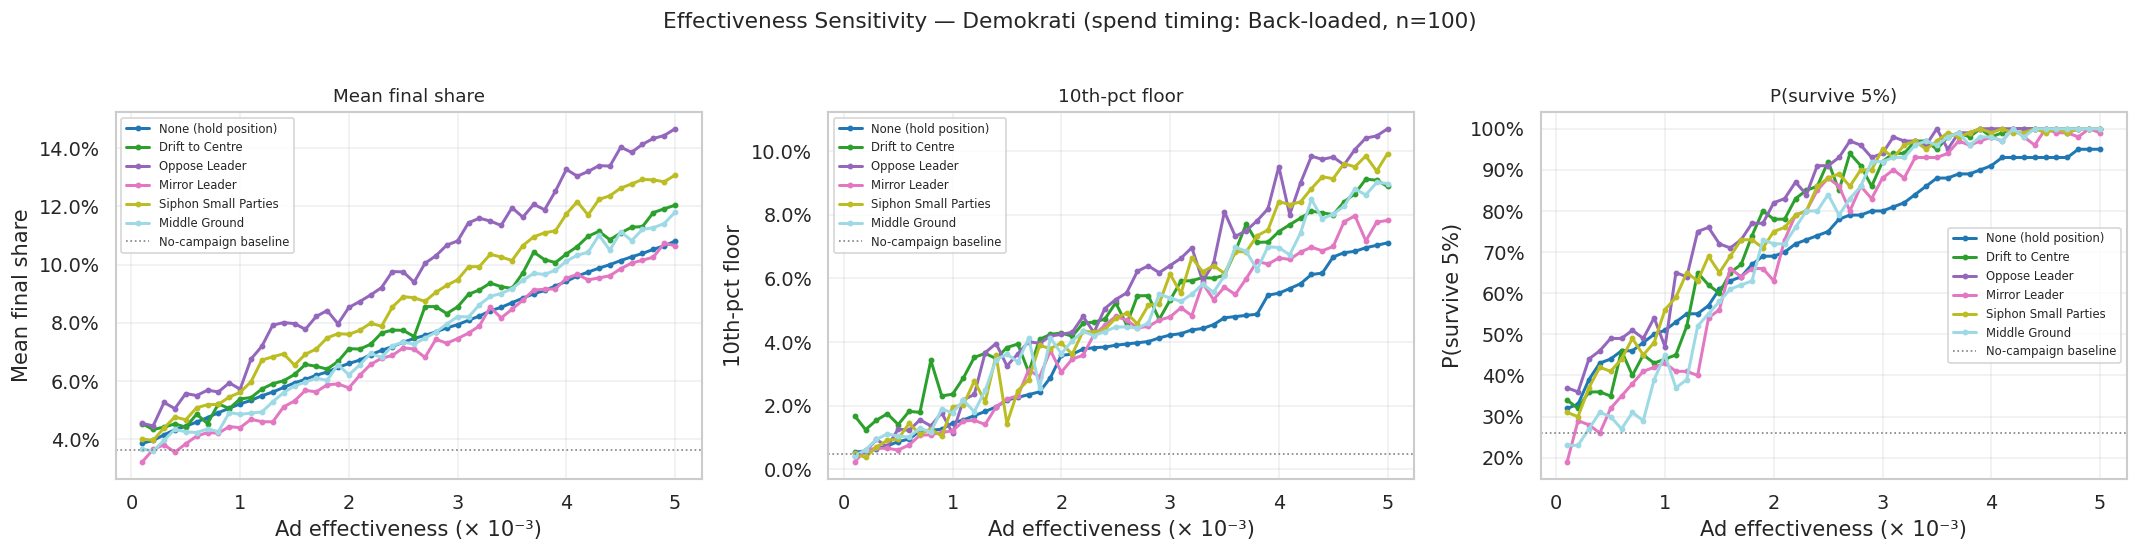

In [15]:
EFF_SWEEP  = np.linspace(0.0001, 0.005, 50)
EFF_N_RUNS = 100

eff_moves = list(STRATEGY_NAMES)
cmap_eff  = plt.cm.get_cmap("tab20", len(eff_moves))
print("Strategies:", eff_moves)

eff_records = []
total_eff   = len(eff_moves) * len(EFF_SWEEP)
done_eff    = 0

for move in eff_moves:
    for eff in EFF_SWEEP:
        done_eff += 1
        print(f"  [{done_eff}/{total_eff}] {move} | eff={eff:.4f}")
        r = run_mc_fast(move, best_spend_global, BUDGET, eff, n_runs=EFF_N_RUNS)
        eff_records.append(dict(
            movement      = move,
            effectiveness = eff,
            mean          = r["mean"],
            p10           = r["p10"],
            survive_rate  = r["survive_rate"],
            delta_mean    = r["mean"] - base["mean"],
        ))

df_eff = pd.DataFrame(eff_records)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=False)
metrics = [
    ("mean",         "Mean final share"),
    ("p10",          "10th-pct floor"),
    ("survive_rate", "P(survive 5%)"),
]

for ax, (col, ylabel) in zip(axes, metrics):
    for i, move in enumerate(eff_moves):
        sub = df_eff[df_eff["movement"] == move]
        ax.plot(sub["effectiveness"] * 1000, sub[col] * 100,
                marker=".", markersize=5, color=cmap_eff(i), label=move, linewidth=1.8)
    ref = {"mean": base["mean"], "p10": base["p10"],
           "survive_rate": base["survive_rate"]}[col]
    ax.axhline(ref * 100, color="gray", linestyle=":", linewidth=1,
               label="No-campaign baseline")
    ax.set_xlabel("Ad effectiveness (\u00d7 10\u207b\u00b3)")
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(ylabel, fontsize=11)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Effectiveness Sensitivity \u2014 {CAMPAIGN_PARTY} (spend timing: {best_spend_global}, n={EFF_N_RUNS})",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()
